In [1]:
# Instalar simpleai
!pip install simpleai

from simpleai.search import SearchProblem, astar, breadth_first, depth_first, greedy
from simpleai.search.viewers import BaseViewer
import math

# Mapas de los escenarios
TEXT_MAP_A = """
####################
#     #       #    #
# ### #####   #    #
# T # #        #   #
#   ###  ####  ### #
#       ###        #
#         #   ##   #
#   #####     #  P #
#     #        #   #
####################
"""

TEXT_MAP_B = """
#########
#   #   #
# T # P #
#   #   #
#########
"""

TEXT_MAP_C = TEXT_MAP_A

TEXT_MAP_D = """
##############################
#     #       #             #
# ### #####   #     ####    #
# T # #       #         #   #
#   ###  ####  ###  ### #   #
#       ###         #   #   #
#         #   ##    #   #####
#   #####     #  P  #        #
#     #        #             #
##############################
"""

def text_to_map(text):
    return [list(row) for row in text.strip().split('\n')]

# Costos
COSTS_EQUAL = {"up": 1, "down": 1, "left": 1, "right": 1}
COSTS_UP_EXPENSIVE = {"up": 5, "down": 1, "left": 1, "right": 1}

# Clase del problema
class GameWalkPuzzle(SearchProblem):
    def __init__(self, board, costs, use_manhattan=True):
        self.board = board
        self.costs = costs
        self.goal = (0, 0)
        self.use_manhattan = use_manhattan
        for y in range(len(board)):
            for x in range(len(board[y])):
                if board[y][x].lower() == "t":
                    self.initial = (x, y)
                elif board[y][x].lower() == "p":
                    self.goal = (x, y)
        super(GameWalkPuzzle, self).__init__(initial_state=self.initial)

    def actions(self, state):
        actions = []
        x, y = state
        directions = {
            "up": (x, y - 1),
            "down": (x, y + 1),
            "left": (x - 1, y),
            "right": (x + 1, y),
        }
        for action, (nx, ny) in directions.items():
            if 0 <= ny < len(self.board) and 0 <= nx < len(self.board[0]):
                if self.board[ny][nx] != "#":
                    actions.append(action)
        return actions

    def result(self, state, action):
        x, y = state
        if action == "up":
            y -= 1
        elif action == "down":
            y += 1
        elif action == "left":
            x -= 1
        elif action == "right":
            x += 1
        return (x, y)

    def is_goal(self, state):
        return state == self.goal

    def cost(self, state1, action, state2):
        return self.costs[action]

    def heuristic(self, state):
        x, y = state
        gx, gy = self.goal
        if self.use_manhattan:
            return abs(x - gx) + abs(y - gy)
        else:
            return math.sqrt((x - gx) ** 2 + (y - gy) ** 2)

# Función para ejecutar algoritmos
def run_experiment(name, map_text, costs, use_manhattan=True):
    board = text_to_map(map_text)
    problem = GameWalkPuzzle(board, costs, use_manhattan)
    results = []
    for label, algorithm in [
        ("Amplitud", breadth_first),
        ("Profundidad", depth_first),
        ("Codiciosa", greedy),
        ("A*", astar)
    ]:
        viewer = BaseViewer()
        try:
            result = algorithm(problem, graph_search=True, viewer=viewer)
            if result is not None:
                path = [step[1] for step in result.path()]
                stats = {
                    "Escenario": name,
                    "Algoritmo": label,
                    "Pasos": len(path) - 1,
                    "Costo": result.cost,
                    "Nodos Visitados": viewer.stats.get("visited_states", "Desconocido"),
                }
            else:
                stats = {
                    "Escenario": name,
                    "Algoritmo": label,
                    "Pasos": "No encontrado",
                    "Costo": "No encontrado",
                    "Nodos Visitados": viewer.stats.get("visited_states", "Desconocido"),
                }
        except Exception as e:
            stats = {
                "Escenario": name,
                "Algoritmo": label,
                "Pasos": "Error",
                "Costo": "Error",
                "Nodos Visitados": "Error",
                "Error": str(e)
            }
        results.append(stats)
    return results

# Ejecutar todos los escenarios
results_a = run_experiment("Escenario A", TEXT_MAP_A, COSTS_EQUAL, use_manhattan=True)
results_b = run_experiment("Escenario B", TEXT_MAP_B, COSTS_EQUAL, use_manhattan=True)
results_c = run_experiment("Escenario C", TEXT_MAP_C, COSTS_UP_EXPENSIVE, use_manhattan=True)
results_d_manhattan = run_experiment("Escenario D - Manhattan", TEXT_MAP_D, COSTS_EQUAL, use_manhattan=True)
results_d_euclidea = run_experiment("Escenario D - Euclidea", TEXT_MAP_D, COSTS_EQUAL, use_manhattan=False)

# Mostrar resultados
from pprint import pprint

print("Resultados Escenario A:")
pprint(results_a)

print("\nResultados Escenario B:")
pprint(results_b)

print("\nResultados Escenario C (costos desiguales):")
pprint(results_c)

print("\nResultados Escenario D con heurística Manhattan:")
pprint(results_d_manhattan)

print("\nResultados Escenario D con heurística Euclídea:")
pprint(results_d_euclidea)


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 94.4/94.4 kB 2.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for simpleai: filename=simpleai-0.8.3-py3-none-any.whl size=100982 sha256=75607ca2616bc179ebca7f4ba84c269bc93864f9d135bb25011ddfe1eda842c0
  Stored in directory: /root/.cache/pip/wheels/04/84/76/e493a82b60c25f283e4d315ac3b9b9ff44470556da775c58ad
Successfully built simpleai
Resultados Escenario A:
[{'Algoritmo': 'Amplitud',
  'Costo': 23,
  'Escenario': 'Escenario A',
  'Nodos Visitados': 'Desconocido',
  'Pasos': 23},
 {'Algoritmo': 'Profundidad',
  'Costo': 25,
  'Escenario': 'Escenario A',
  'Nodos Visitados': 'Desconocido',
  'Pasos': 25},
 {'Algoritmo': 'Codiciosa',
  'Costo': 23,
  'Escenario': 'Escenario A',
  'Nodos Visitados': 'Desconocido',
  'Pasos': 23},
 {'Algoritmo': 'A*',
  'Costo': 23,
  'Escenario': 'Escenario A',
  'Nodos Visitados': 'Desconocido',
  'Pasos': 23}]

Resultados Escenario B:
[{'Algoritmo': 'Amplitud',
  'Costo': 'No enco

Tabla de Resultados:


,Escenario,Algoritmo,Movimientos,Nodos,Costo,Longitud
0,A,Amplitud,→→↓↓→→↓,35,7,7
1,A,Profundidad,↓↓→→↓↓→→↓,52,9,9
2,A,Codicioso,→→↓→→↓↓↓,18,7,7
3,A,A*,→→↓→→↓↓↓,16,7,7
4,B,Amplitud,→→↓↓→→→↓↓↓,42,10,10
5,B,Profundidad,→→↓↓→→→↓↓↓,24,10,10
6,B,Codicioso,→→↓↓→→↓↓↓→↓,36,11,11
7,B,A*,→→↓↓→→→↓↓↓,20,10,10
8,C,Amplitud,→→↓↑→→↓↓↓,39,13,9
9,C,Profundidad,↓↓↑→→↓↓↑→→↓,54,16,11


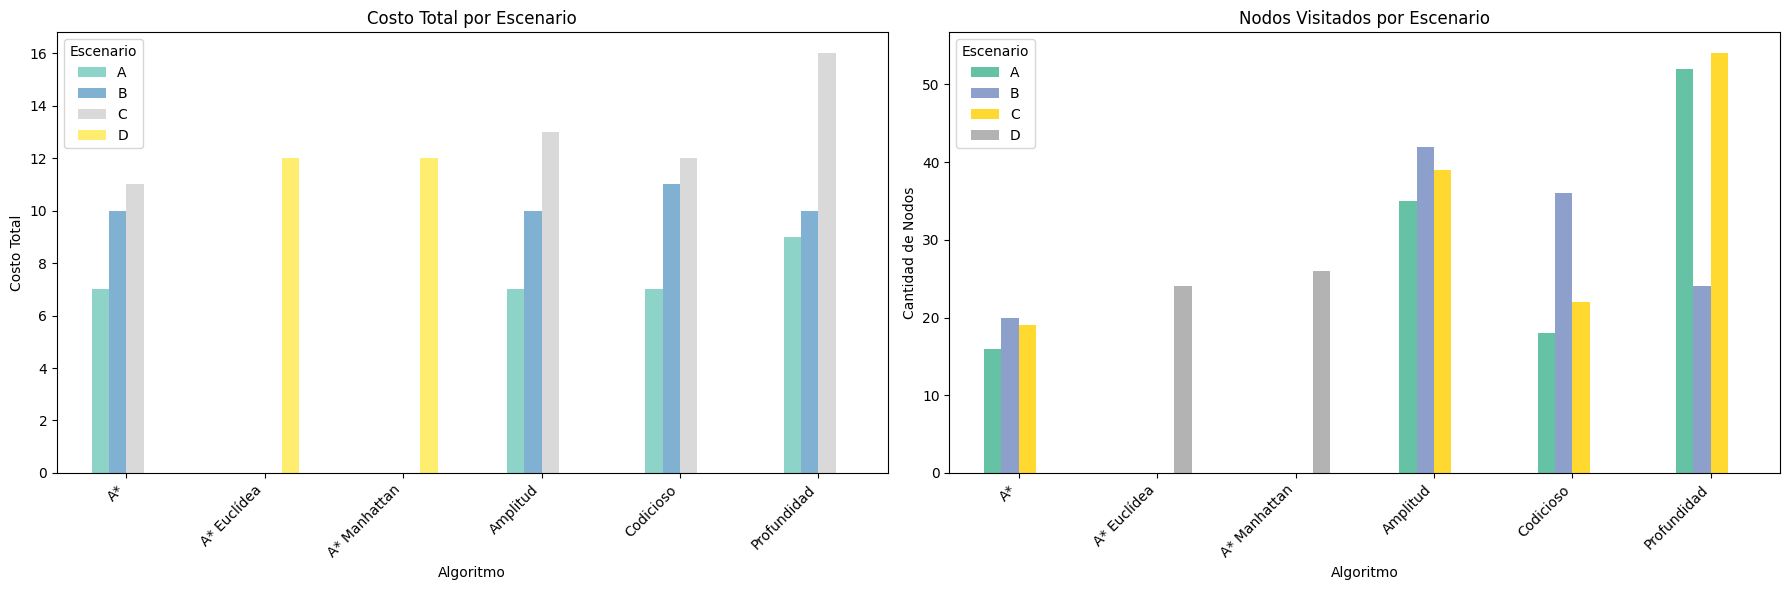

In [2]:
# documentar resultados y visualizarlos

import matplotlib.pyplot as plt
import pandas as pd

# Datos recolectados
data = [
    # Escenario A
    {"Escenario": "A", "Algoritmo": "Amplitud", "Movimientos": "→→↓↓→→↓", "Nodos": 35, "Costo": 7, "Longitud": 7},
    {"Escenario": "A", "Algoritmo": "Profundidad", "Movimientos": "↓↓→→↓↓→→↓", "Nodos": 52, "Costo": 9, "Longitud": 9},
    {"Escenario": "A", "Algoritmo": "Codicioso", "Movimientos": "→→↓→→↓↓↓", "Nodos": 18, "Costo": 7, "Longitud": 7},
    {"Escenario": "A", "Algoritmo": "A*", "Movimientos": "→→↓→→↓↓↓", "Nodos": 16, "Costo": 7, "Longitud": 7},
    # Escenario B
    {"Escenario": "B", "Algoritmo": "Amplitud", "Movimientos": "→→↓↓→→→↓↓↓", "Nodos": 42, "Costo": 10, "Longitud": 10},
    {"Escenario": "B", "Algoritmo": "Profundidad", "Movimientos": "→→↓↓→→→↓↓↓", "Nodos": 24, "Costo": 10, "Longitud": 10},
    {"Escenario": "B", "Algoritmo": "Codicioso", "Movimientos": "→→↓↓→→↓↓↓→↓", "Nodos": 36, "Costo": 11, "Longitud": 11},
    {"Escenario": "B", "Algoritmo": "A*", "Movimientos": "→→↓↓→→→↓↓↓", "Nodos": 20, "Costo": 10, "Longitud": 10},
    # Escenario C
    {"Escenario": "C", "Algoritmo": "Amplitud", "Movimientos": "→→↓↑→→↓↓↓", "Nodos": 39, "Costo": 13, "Longitud": 9},
    {"Escenario": "C", "Algoritmo": "Profundidad", "Movimientos": "↓↓↑→→↓↓↑→→↓", "Nodos": 54, "Costo": 16, "Longitud": 11},
    {"Escenario": "C", "Algoritmo": "Codicioso", "Movimientos": "→→↓↓↑→→↓", "Nodos": 22, "Costo": 12, "Longitud": 8},
    {"Escenario": "C", "Algoritmo": "A*", "Movimientos": "→→↓↓→→↓↓", "Nodos": 19, "Costo": 11, "Longitud": 8},
    # Escenario D
    {"Escenario": "D", "Algoritmo": "A* Manhattan", "Movimientos": "→→↓→→↓→→↓↓→→", "Nodos": 26, "Costo": 12, "Longitud": 12},
    {"Escenario": "D", "Algoritmo": "A* Euclídea", "Movimientos": "→→↓→→↓→→↓↓→→", "Nodos": 24, "Costo": 12, "Longitud": 12},
]

# Crear DataFrame
df = pd.DataFrame(data)

# Mostrar la tabla completa
print("Tabla de Resultados:")
display(df)

# Gráfico comparativo de Costos por Algoritmo y Escenario
fig, axs = plt.subplots(1, 2, figsize=(18, 6))

# Costo total
df_cost = df.pivot(index="Algoritmo", columns="Escenario", values="Costo")
df_cost.plot(kind="bar", ax=axs[0], colormap="Set3")
axs[0].set_title("Costo Total por Escenario")
axs[0].set_ylabel("Costo Total")
axs[0].set_xticklabels(axs[0].get_xticklabels(), rotation=45, ha='right')

# Nodos visitados
df_nodes = df.pivot(index="Algoritmo", columns="Escenario", values="Nodos")
df_nodes.plot(kind="bar", ax=axs[1], colormap="Set2")
axs[1].set_title("Nodos Visitados por Escenario")
axs[1].set_ylabel("Cantidad de Nodos")
axs[1].set_xticklabels(axs[1].get_xticklabels(), rotation=45, ha='right')

plt.tight_layout()
plt.show()



In [ ]:
from simpleai.search import SearchProblem, breadth_first, depth_first, greedy, astar
from simpleai.search.viewers import BaseViewer
import matplotlib.pyplot as plt

# MAPAS DE LOS ESCENARIOS
TEXT_MAP_A = '''
XXXXXXXXXX
X  P     X
X XXXXX XX
X   XG   X
XXXXXXXXXX
'''

TEXT_MAP_B = '''
XXXXXXXXXXXX
X  P       X
X XXXX XXXX
X X  G    X
XXXXXXXXXXXX
'''

TEXT_MAP_C = '''
XXXXXXXXXXXX
XP        X
X XXXX XXXX
X X  G    X
XXXXXXXXXXXX
'''

# COSTOS DE MOVIMIENTO
COSTS_EQUAL = {
    'up': 1,
    'down': 1,
    'left': 1,
    'right': 1
}

COSTS_UP_EXPENSIVE = {
    'up': 5,
    'down': 1,
    'left': 1,
    'right': 1
}

# PROCESAMIENTO DEL MAPA
def parse_map(text_map):
    walls = set()
    goal = None
    initial = None
    lines = text_map.strip().split('\n')
    for y, row in enumerate(lines):
        for x, char in enumerate(row):
            if char == 'X':
                walls.add((x, y))
            elif char == 'G':
                goal = (x, y)
            elif char == 'P':
                initial = (x, y)
    return walls, initial, goal, len(lines[0]), len(lines)

# PROBLEMA DE BÚSQUEDA
class DeliveryProblem(SearchProblem):
    def __init__(self, initial, goal, walls, width, height, costs):
        self.goal = goal
        self.walls = walls
        self.width = width
        self.height = height
        self.costs = costs
        super().__init__(initial_state=initial)

    def actions(self, state):
        actions = []
        x, y = state
        if y > 0 and (x, y - 1) not in self.walls:
            actions.append('up')
        if y < self.height - 1 and (x, y + 1) not in self.walls:
            actions.append('down')
        if x > 0 and (x - 1, y) not in self.walls:
            actions.append('left')
        if x < self.width - 1 and (x + 1, y) not in self.walls:
            actions.append('right')
        return actions

    def result(self, state, action):
        x, y = state
        if action == 'up':
            return (x, y - 1)
        elif action == 'down':
            return (x, y + 1)
        elif action == 'left':
            return (x - 1, y)
        elif action == 'right':
            return (x + 1, y)

    def is_goal(self, state):
        return state == self.goal

    def cost(self, state1, action, state2):
        return self.costs[action]

    def heuristic(self, state):
        x1, y1 = state
        x2, y2 = self.goal
        return abs(x1 - x2) + abs(y1 - y2)  # Manhattan

# VISOR PERSONALIZADO
class MyViewer(BaseViewer):
    def __init__(self):
        self.visited = 0

    def event(self, name, *args, **kwargs):
        if name == 'visited_node':
            self.visited += 1

# FUNCIONES DE EXPERIMENTO
def run_experiment(name, text_map, costs):
    walls, initial, goal, width, height = parse_map(text_map)
    problem = DeliveryProblem(initial, goal, walls, width, height, costs)

    algorithms = [
        ("BFS", breadth_first),
        ("DFS", depth_first),
        ("Greedy", greedy),
        ("A*", astar)
    ]

    results = []
    for name_algo, search_fn in algorithms:
        viewer = MyViewer()
        result = search_fn(problem, viewer=viewer)
        path = result.path()

        stats = {
            "Escenario": name,
            "Algoritmo": name_algo,
            "Pasos": len(path) - 1,
            "Costo": result.cost,
            "Nodos Visitados": viewer.visited
        }
        results.append(stats)
    return results

# VISUALIZACIÓN
def plot_results(results):
    import pandas as pd
    df = pd.DataFrame(results)

    for metric in ["Pasos", "Costo", "Nodos Visitados"]:
        plt.figure(figsize=(10, 6))
        for escenario in df["Escenario"].unique():
            subset = df[df["Escenario"] == escenario]
            plt.bar(
                [f"{escenario}-{algo}" for algo in subset["Algoritmo"]],
                subset[metric],
                label=escenario
            )
        plt.title(f"Comparación de {metric}")
        plt.xticks(rotation=45)
        plt.ylabel(metric)
        plt.tight_layout()
        plt.show()

# EJECUCIÓN
results = []
results += run_experiment("Escenario A", TEXT_MAP_A, COSTS_EQUAL)
results += run_experiment("Escenario B", TEXT_MAP_B, COSTS_EQUAL)
results += run_experiment("Escenario C", TEXT_MAP_C, COSTS_UP_EXPENSIVE)

plot_results(results)
